In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import hanoi

Read data

In [71]:
d = pd.read_csv("data/L1_n1/L1_n1_multimodal.txt", delimiter=" ")

In [72]:
d.head()

,sigma,m0,m1,v0,v1,n_gen,allele_fixed
0,0.316228,-1.0,-1.0,0.01,0.01,38,1.0
1,0.316228,-1.0,-1.0,0.01,0.01,300,0.0
2,0.316228,-1.0,-1.0,0.01,0.01,144,1.0
3,0.316228,-1.0,-1.0,0.01,0.01,95,1.0
4,0.316228,-1.0,-1.0,0.01,0.01,305,0.0


In [60]:
d_gb = d.groupby(["sigma", "m0", "m1", "v0", "v1"])

In [61]:
d_gb

Extinction prob.

In [62]:
d_gb.agg(p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
         p_fix_1 = ("allele_fixed", "mean")
        ).reset_index()

,sigma,m0,m1,v0,v1,p_ext,p_fix_1
0,0.316228,-1.0,-1.0,0.01,0.010000,0.0,0.48
1,0.316228,-1.0,-1.0,0.01,0.015849,0.0,1.00
2,0.316228,-1.0,-1.0,0.01,0.025119,0.0,1.00
3,0.316228,-1.0,-1.0,0.01,0.039811,0.0,1.00
4,0.316228,-1.0,-1.0,0.01,0.063096,0.0,1.00
...,...,...,...,...,...,...,...
25595,10.000000,1.0,1.0,10.00,1.584893,0.0,0.96
25596,10.000000,1.0,1.0,10.00,2.511886,0.0,0.98
25597,10.000000,1.0,1.0,10.00,3.981072,0.0,0.96
25598,10.000000,1.0,1.0,10.00,6.309573,0.0,0.79


In [63]:
d_1 = d[d["allele_fixed"] == 1].groupby(["sigma", "m0", "m1", "v0", "v1"])

In [64]:
d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index()

,sigma,m0,m1,v0,v1,t_fix_1
0,0.316228,-1.0,-1.0,0.01,0.010000,126.229167
1,0.316228,-1.0,-1.0,0.01,0.015849,39.010000
2,0.316228,-1.0,-1.0,0.01,0.025119,19.350000
3,0.316228,-1.0,-1.0,0.01,0.039811,13.130000
4,0.316228,-1.0,-1.0,0.01,0.063096,9.030000
...,...,...,...,...,...,...
17552,10.000000,1.0,1.0,10.00,1.584893,147.968750
17553,10.000000,1.0,1.0,10.00,2.511886,163.948980
17554,10.000000,1.0,1.0,10.00,3.981072,181.885417
17555,10.000000,1.0,1.0,10.00,6.309573,243.240506


In [65]:
d_smr = pd.merge(d_gb.agg(
    p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
    p_fix_1 = ("allele_fixed", "mean")).reset_index(),
                 d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index(),
                 on = ["sigma", "m0", "m1", "v0", "v1"],
                 how = "left"
                )

In [66]:
d_smr.head()

,sigma,m0,m1,v0,v1,p_ext,p_fix_1,t_fix_1
0,0.316228,-1.0,-1.0,0.01,0.010000,0.0,0.48,126.229167
1,0.316228,-1.0,-1.0,0.01,0.015849,0.0,1.00,39.010000
2,0.316228,-1.0,-1.0,0.01,0.025119,0.0,1.00,19.350000
3,0.316228,-1.0,-1.0,0.01,0.039811,0.0,1.00,13.130000
4,0.316228,-1.0,-1.0,0.01,0.063096,0.0,1.00,9.030000


In [67]:
d_smr.shape

(25600, 8)

In [68]:
d_smr["log_v0"] = np.log10(d_smr["v0"])
d_smr["log_v1"] = np.log10(d_smr["v1"])

In [69]:
v0_all = np.sort(d_smr["v0"].unique())
v1_all = np.sort(d_smr["v1"].unique())
def heatmap_panel(data, **kwargs):
    table = data.pivot_table(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="viridis", cbar=True, **kwargs)

In [70]:
row_order_m = sorted(d_smr["m1"].unique(), reverse=True)  # top row = largest m1
col_order_m = sorted(d_smr["m0"].unique())

In [54]:
def heatmap_panel(data, **kwargs):
    # pivot inside the panel
    table = data.pivot(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="coolwarm", vmin=0, vmax=1, cbar=False, ax=plt.gca())
    ax = plt.gca()
    ax.invert_yaxis()

    # Get current tick positions
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()

    # Set labels only for every 5th tick
    ax.set_xticklabels([f"$10^{{{int(np.log10(table.columns[int(t)]) )}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(xticks)], rotation=0)
    ax.set_yticklabels([f"$10^{{{int(np.log10(table.index[int(t)]))}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(yticks)])
    # Hide axis labels inside panel
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

In [3]:
z_1D = np.linspace(-5, 5, 101).reshape([101,1])

In [28]:
np.array([[0],[0]])[0,:]

array([0])

In [11]:
?hanoi.fit_multimodal

Signature: hanoi.fit_multimodal(sigma, p, z_opt, z)
Docstring:
sigma:  (n_peaks,) array specifying SD of n_peak peaks
p:      (n_peaks,) array specifying relative height of peaks
z_opt:  (n_peaks, n) array specifying the coordinate of n_peak peaks in the n-dimensional phenotype space
z:      (N, n) array representing n-dimensional phenotypes of N individuals.
Returns: (N,) array representing fitness of N individuals
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function

In [29]:
hanoi.fit_multimodal(z_opt = np.array([-0.5, 0.5]).reshape((2,1)), sigma = np.sqrt(1) * np.array([1,1]), p = [1,1],z = z_1D)

array([4.03352552e-05, 6.29870753e-05, 9.73883531e-05, 1.49092173e-04,
       2.25994850e-04, 3.39189281e-04, 5.04068989e-04, 7.41731923e-04,
       1.08073302e-03, 1.55923003e-03, 2.22755642e-03, 3.15123691e-03,
       4.41443342e-03, 6.12377126e-03, 8.41244681e-03, 1.14444592e-02,
       1.54187415e-02, 2.05728972e-02, 2.71861761e-02, 3.55812654e-02,
       4.61244247e-02, 5.92234782e-02, 7.53231937e-02, 9.48976404e-02,
       1.18439226e-01, 1.46444280e-01, 1.79395243e-01, 2.17739794e-01,
       2.61867486e-01, 3.12084755e-01, 3.68589401e-01, 4.31445862e-01,
       5.00562712e-01, 5.75673873e-01, 6.56324952e-01, 7.41865943e-01,
       8.31451267e-01, 9.24047736e-01, 1.01845061e+00, 1.11330751e+00,
       1.20714937e+00, 1.29842745e+00, 1.38555484e+00, 1.46695093e+00,
       1.54108691e+00, 1.60653066e+00, 1.66198929e+00, 1.70634771e+00,
       1.73870202e+00, 1.75838656e+00, 1.76499381e+00, 1.75838656e+00,
       1.73870202e+00, 1.70634771e+00, 1.66198929e+00, 1.60653066e+00,
      

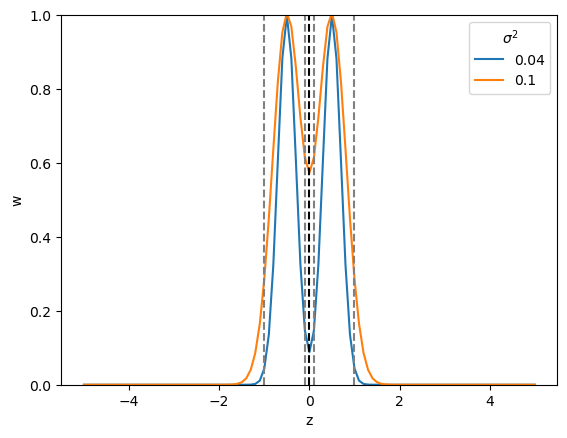

In [30]:
sigma2s = np.array([0.04,0.1])
w_1D_s = np.array([hanoi.fit_multimodal(z_opt = np.array([-0.5, 0.5]).reshape((2,1)), sigma = np.sqrt(sigma2) * np.array([1,1]), p = [1,1],z = z_1D) for sigma2 in sigma2s])
[plt.plot(z_1D, w_1D_s[i,:], label = sigma2s[i]) for i in range(len(sigma2s))]
plt.legend(title='$\sigma^2$')
plt.vlines(x=np.array([-1, -0.1, 0,0.1, 1]), ymin = 0, ymax = 1.1, colors = ["gray", "gray","black", "gray", "gray"], linestyles="--")
plt.xlabel("z")
plt.ylabel("w")
plt.ylim(0, 1)
plt.savefig("L1_n1_multimodal_fitness_funcs.pdf", bbox_inches="tight")
plt.show()

In [57]:
d_smr["sigma"].unique()

array([ 0.31622777,  1.        ,  3.16227766, 10.        ])

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10846/1068030946.py:7: SyntaxWarning: invalid escape sequence '\s'
  g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')


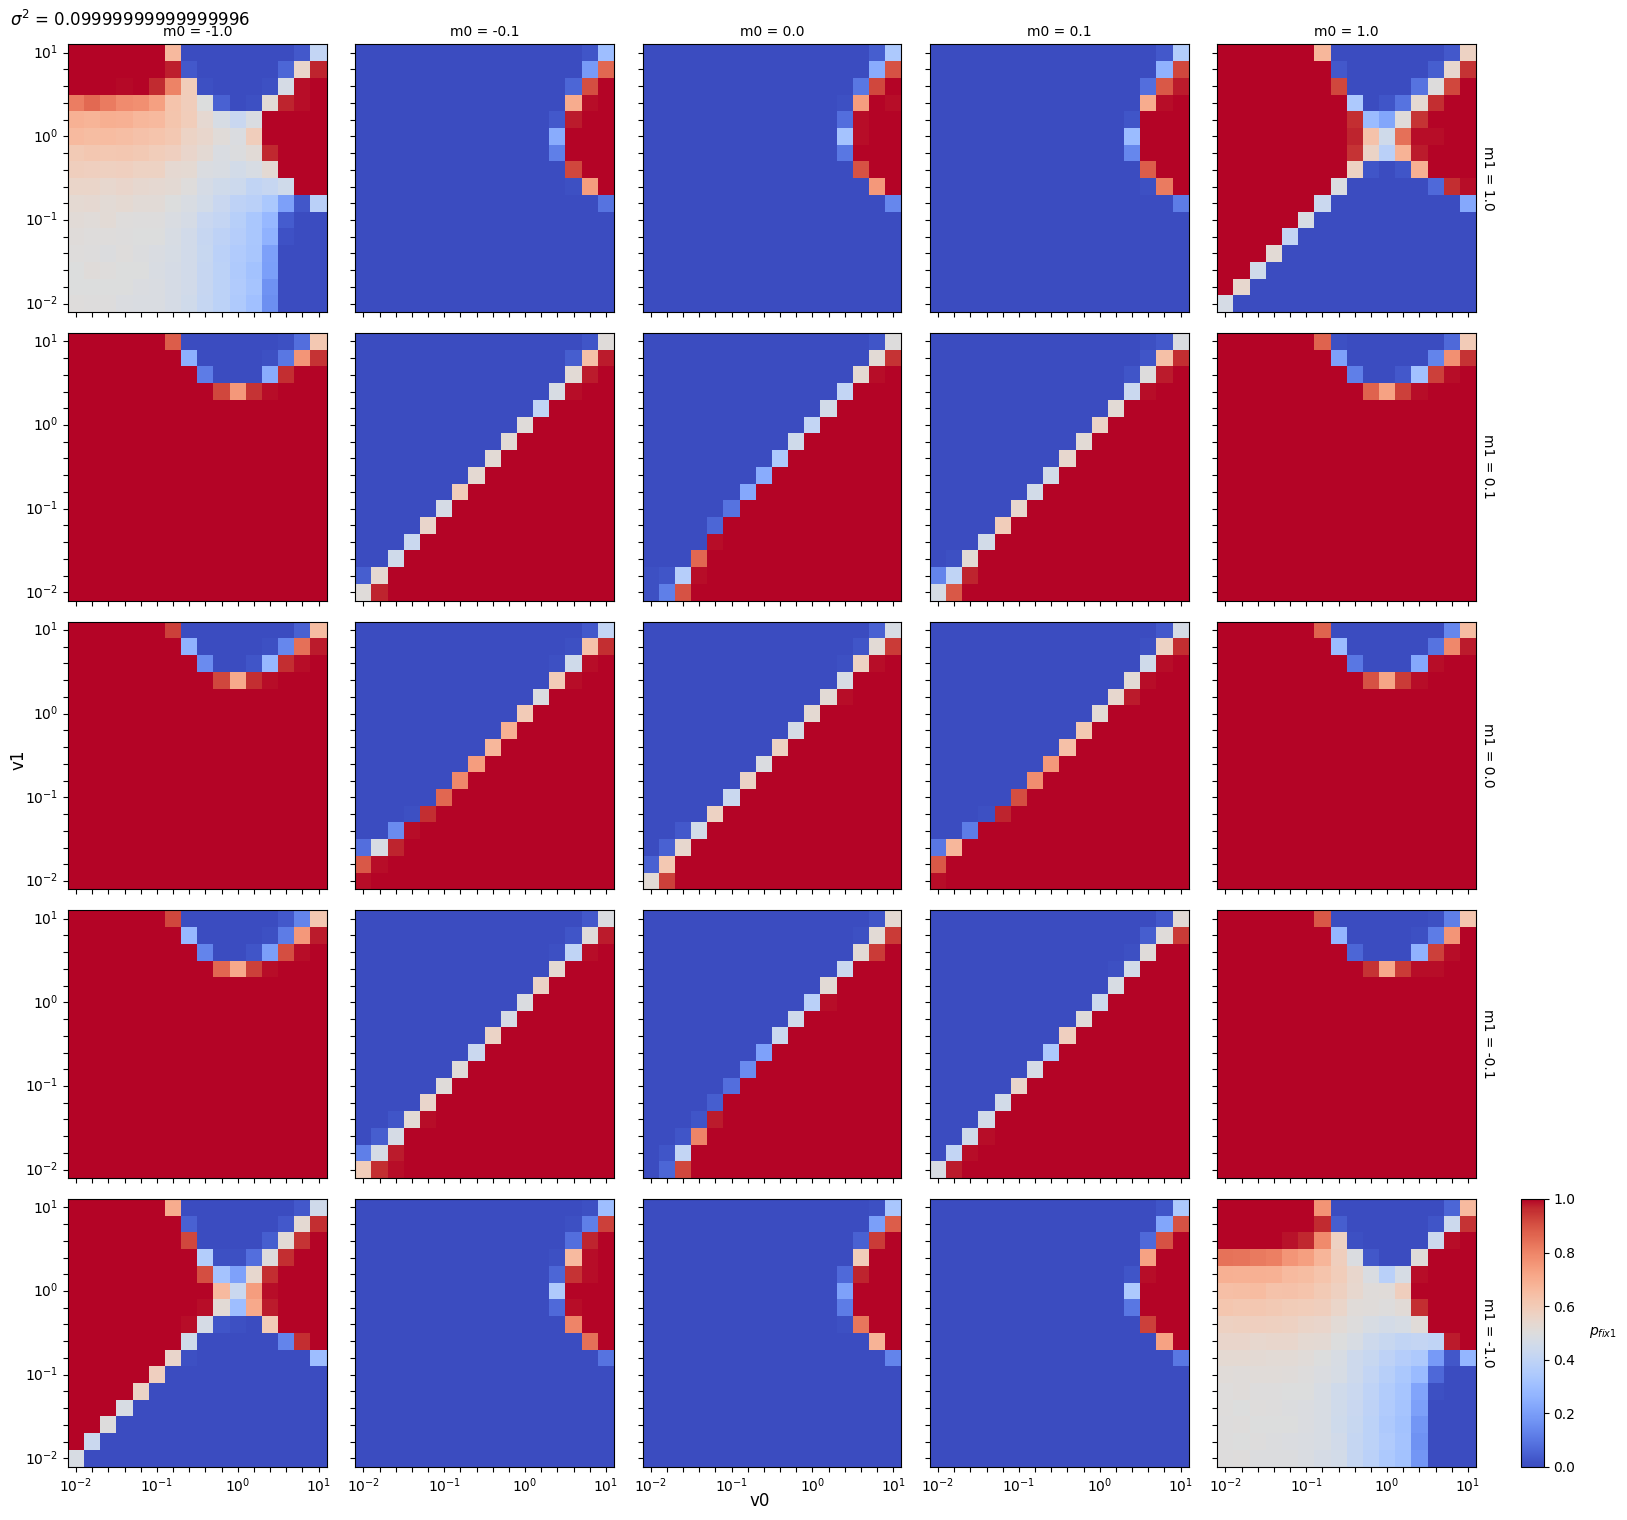

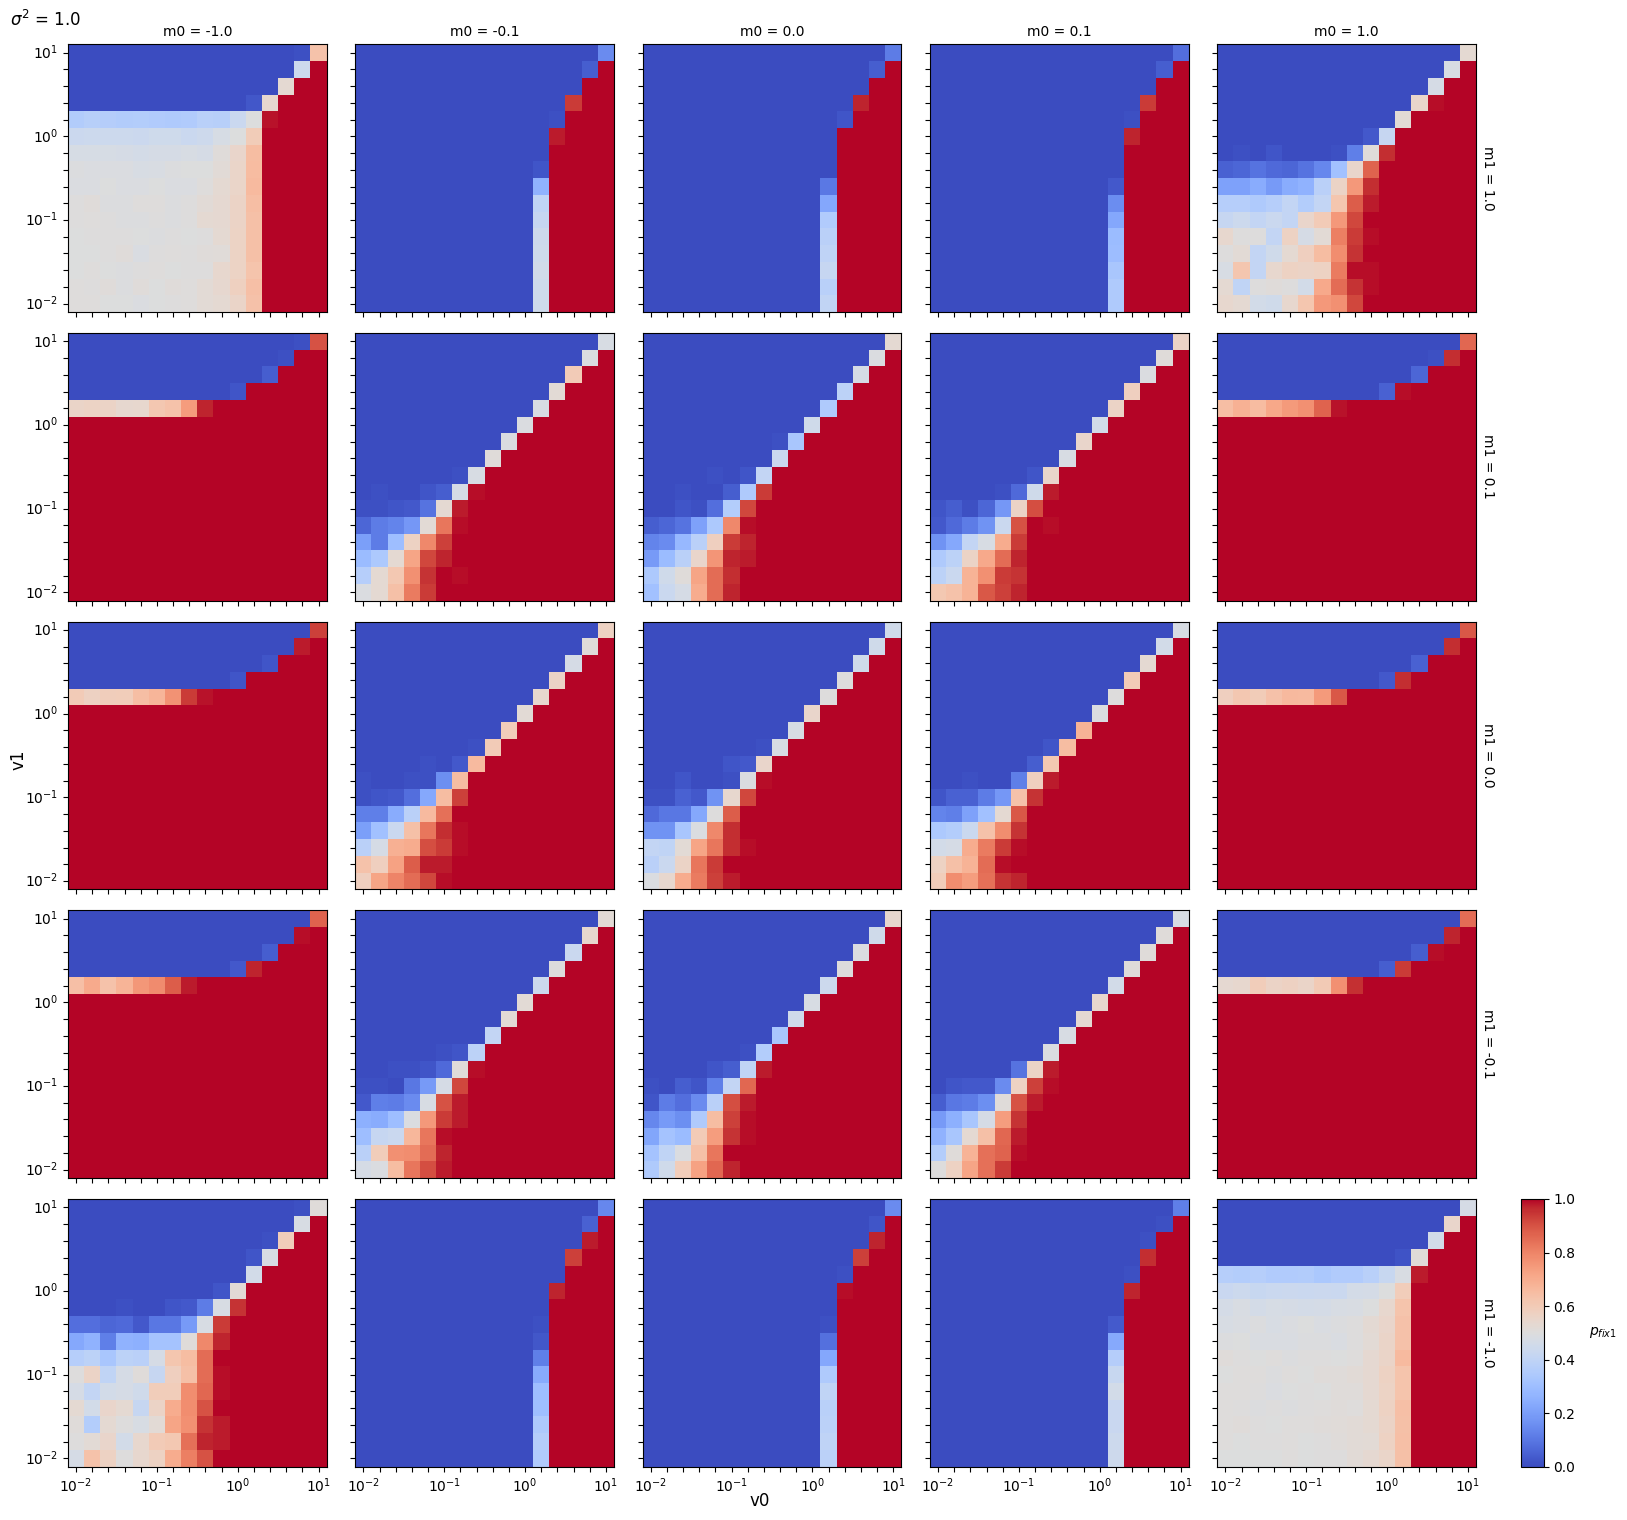

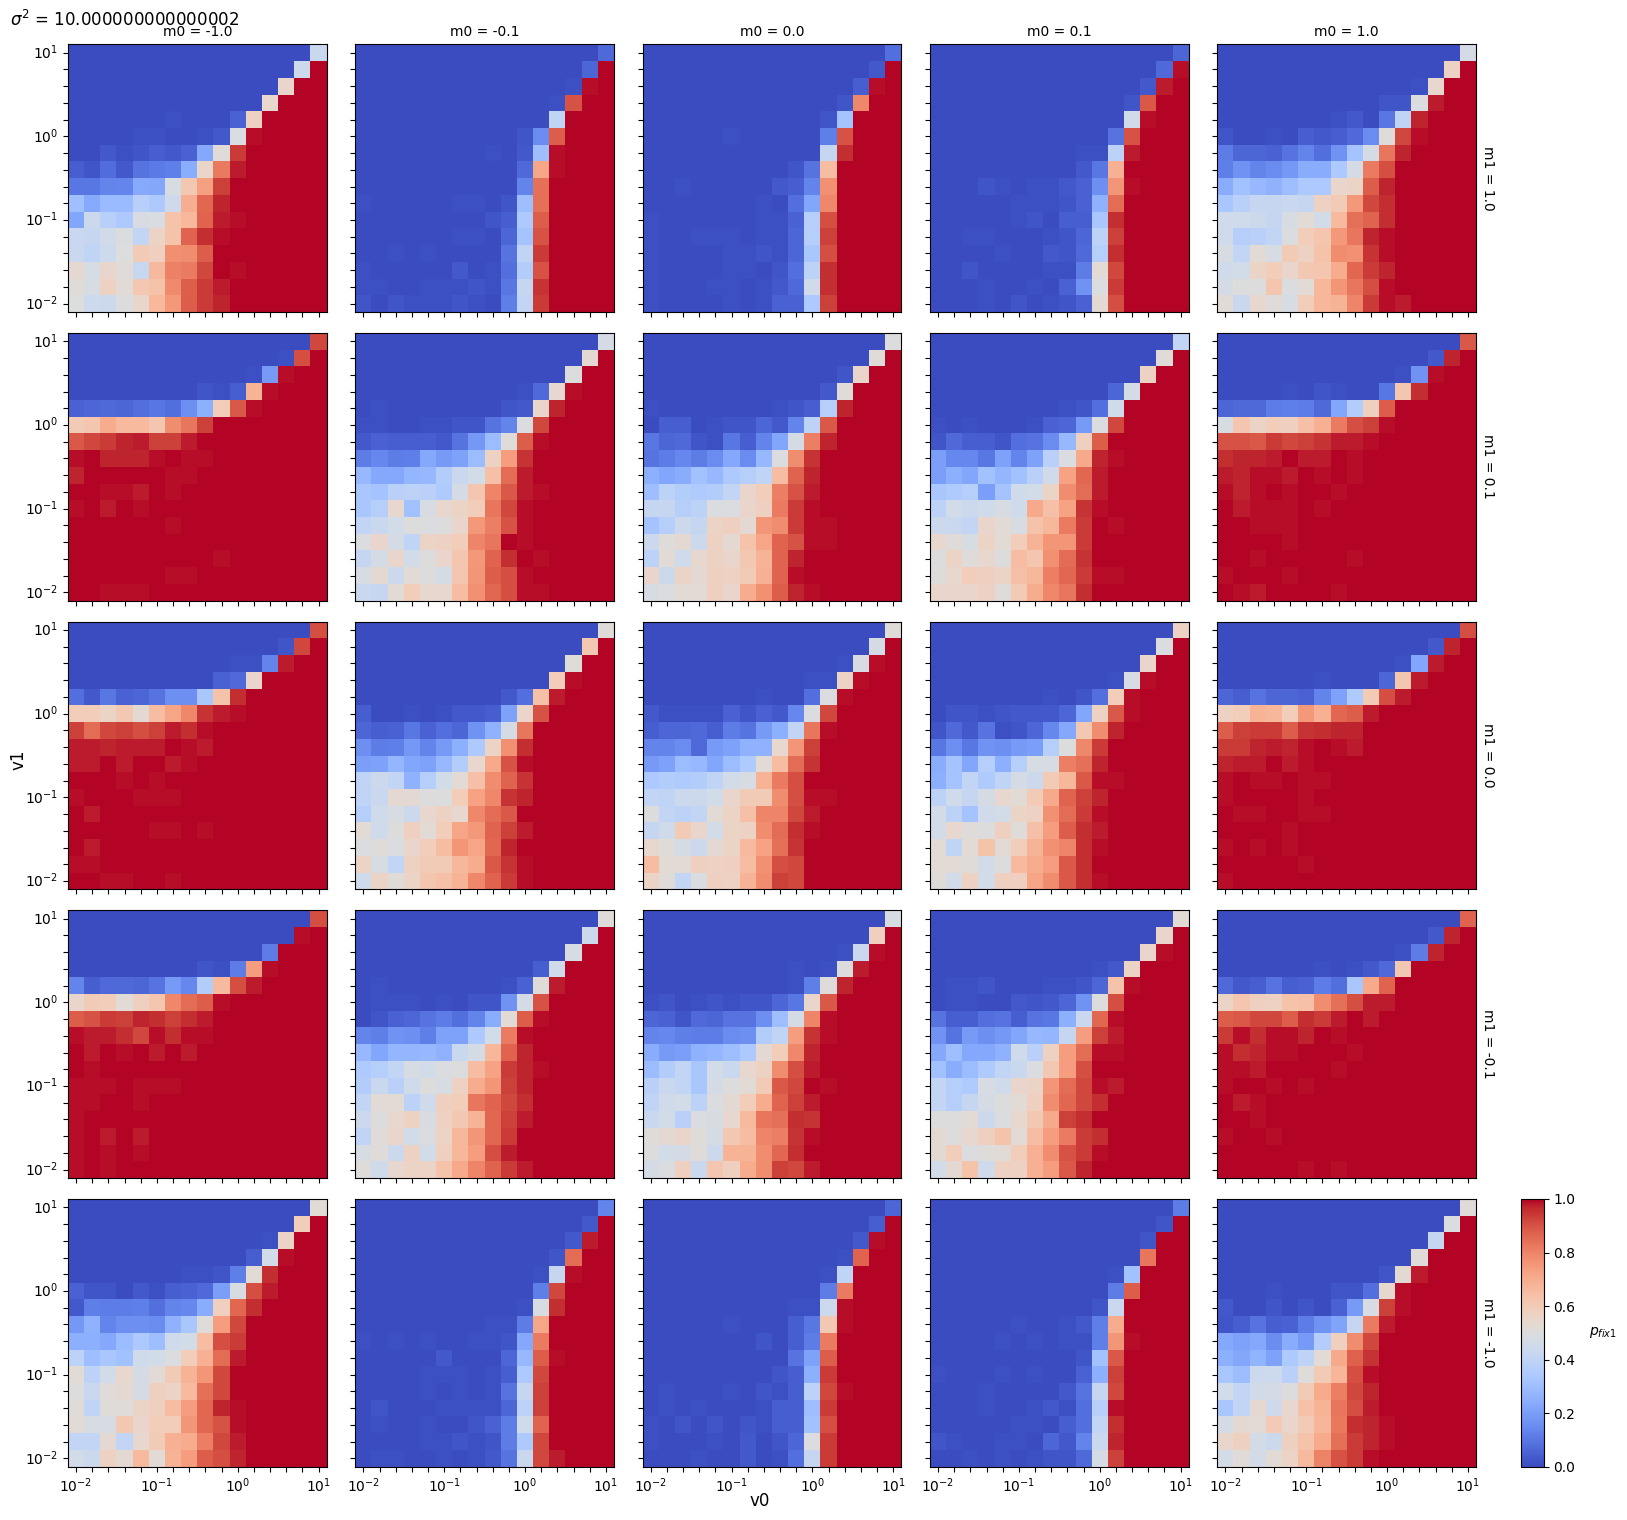

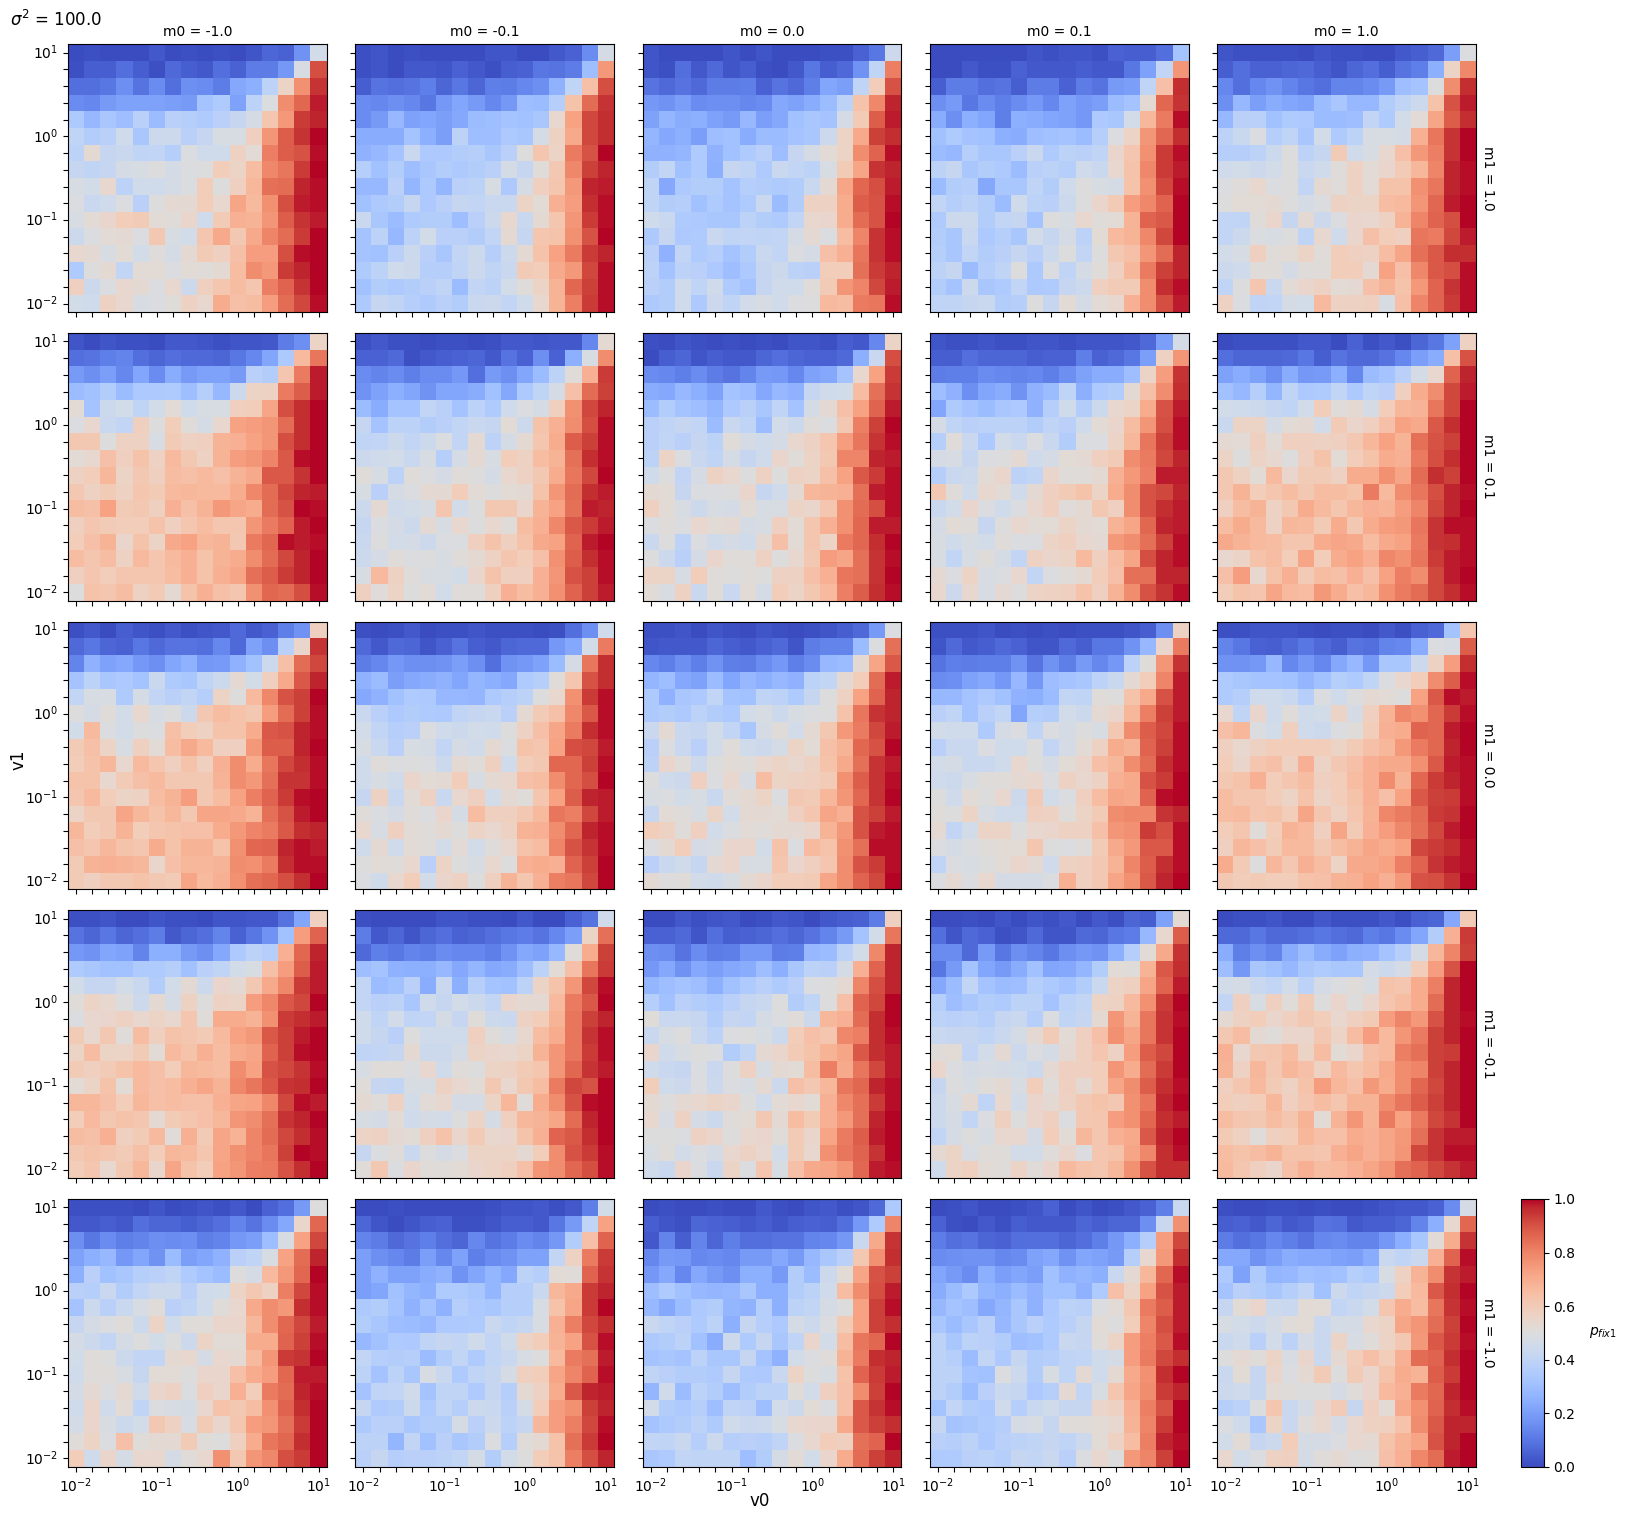

In [23]:
for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]
    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
    g.map_dataframe(heatmap_panel)
    g.fig.supxlabel("v0", x = 0.5, y = 0)
    g.fig.supylabel('v1', y = 0.5, x = 0)
    g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')
    
    # Add a colorbar next to the last panel
    # Compute position of the last panel
    last_ax = g.axes[-1, -1]  # last row, last column
    pos = last_ax.get_position()  # Bbox
    
    # Create a new Axes for the colorbar: slightly thinner than a panel
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
    # Use the same colormap and normalization
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    #g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')
    
    plt.show()
    g.fig.savefig(f"L1_n1_multimodal_sigma2_{sigma**2}_summary.svg", format="svg", bbox_inches="tight")
    g.fig.savefig(f"L1_n1_multimodal_sigma2_{sigma**2}_summary.pdf", format="pdf", bbox_inches="tight")

In [ ]:
for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]
    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
    g.map_dataframe(heatmap_panel)
    g.fig.supxlabel("v0", x = 0.5, y = 0)
    g.fig.supylabel('v1', y = 0.5, x = 0)
    g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')
    
    # Add a colorbar next to the last panel
    # Compute position of the last panel
    last_ax = g.axes[-1, -1]  # last row, last column
    pos = last_ax.get_position()  # Bbox
    
    # Create a new Axes for the colorbar: slightly thinner than a panel
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
    # Use the same colormap and normalization
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    #g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')
    
    plt.show()

In [22]:
d_smr

,sigma,m0,m1,v0,v1,p_ext,p_fix_1,t_fix_1,log_v0,log_v1
0,0.316228,-1.0,-1.0,0.01,0.010000,0.0,0.48,126.229167,-2.0,-2.0
1,0.316228,-1.0,-1.0,0.01,0.015849,0.0,1.00,39.010000,-2.0,-1.8
2,0.316228,-1.0,-1.0,0.01,0.025119,0.0,1.00,19.350000,-2.0,-1.6
3,0.316228,-1.0,-1.0,0.01,0.039811,0.0,1.00,13.130000,-2.0,-1.4
4,0.316228,-1.0,-1.0,0.01,0.063096,0.0,1.00,9.030000,-2.0,-1.2
...,...,...,...,...,...,...,...,...,...,...
25595,10.000000,1.0,1.0,10.00,1.584893,0.0,0.96,147.968750,1.0,0.2
25596,10.000000,1.0,1.0,10.00,2.511886,0.0,0.98,163.948980,1.0,0.4
25597,10.000000,1.0,1.0,10.00,3.981072,0.0,0.96,181.885417,1.0,0.6
25598,10.000000,1.0,1.0,10.00,6.309573,0.0,0.79,243.240506,1.0,0.8


In [21]:
??hanoi.fit_gaus

Signature: hanoi.fit_gaus(sigma, z_opt, z)
Source:   
def fit_gaus(sigma, z_opt, z):
    """
    Computes fitness based on a Gaussian fitness function.

    Arguments:
        sigma: A scalar specifying SD around the peak
        z_opt: (n,) array specifying the coordinate of the peak in the n dimensional phenotypic space
        z:      (N, n) array representing n-dimensional phenotypes of N individuals.
    Returns: (N,) array representing fitness of N individuals
    """
    return np.array([np.exp(-(np.linalg.norm(z_i - z_opt))**2/(2 * sigma**2)) for z_i in z])
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function

In [30]:
def heatmap_panel(data, value_col="p_fix_1", cmap="coolwarm", vmin=0, vmax=1, **kwargs):
    table = data.pivot(index="v1", columns="v0", values=value_col)
    ax = plt.gca()
    sns.heatmap(table, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.invert_yaxis()

    # nicer/robust tick handling: map tick positions to nearest column/index
    cols = np.array(table.columns, dtype=float)
    rows = np.array(table.index, dtype=float)
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    def tick_label_for_pos(pos_array, table_axis):
        # pos_array are tick positions; round to nearest integer index
        out = []
        for i, t in enumerate(pos_array):
            idx = int(round(t))
            if 0 <= idx < len(table_axis) and i % 5 == 0:
                out.append(f"$10^{{{int(np.log10(table_axis[idx]))}}}$")
            else:
                out.append("")
        return out

    ax.set_xticklabels(tick_label_for_pos(xticks, cols), rotation=0)
    ax.set_yticklabels(tick_label_for_pos(yticks, rows))
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

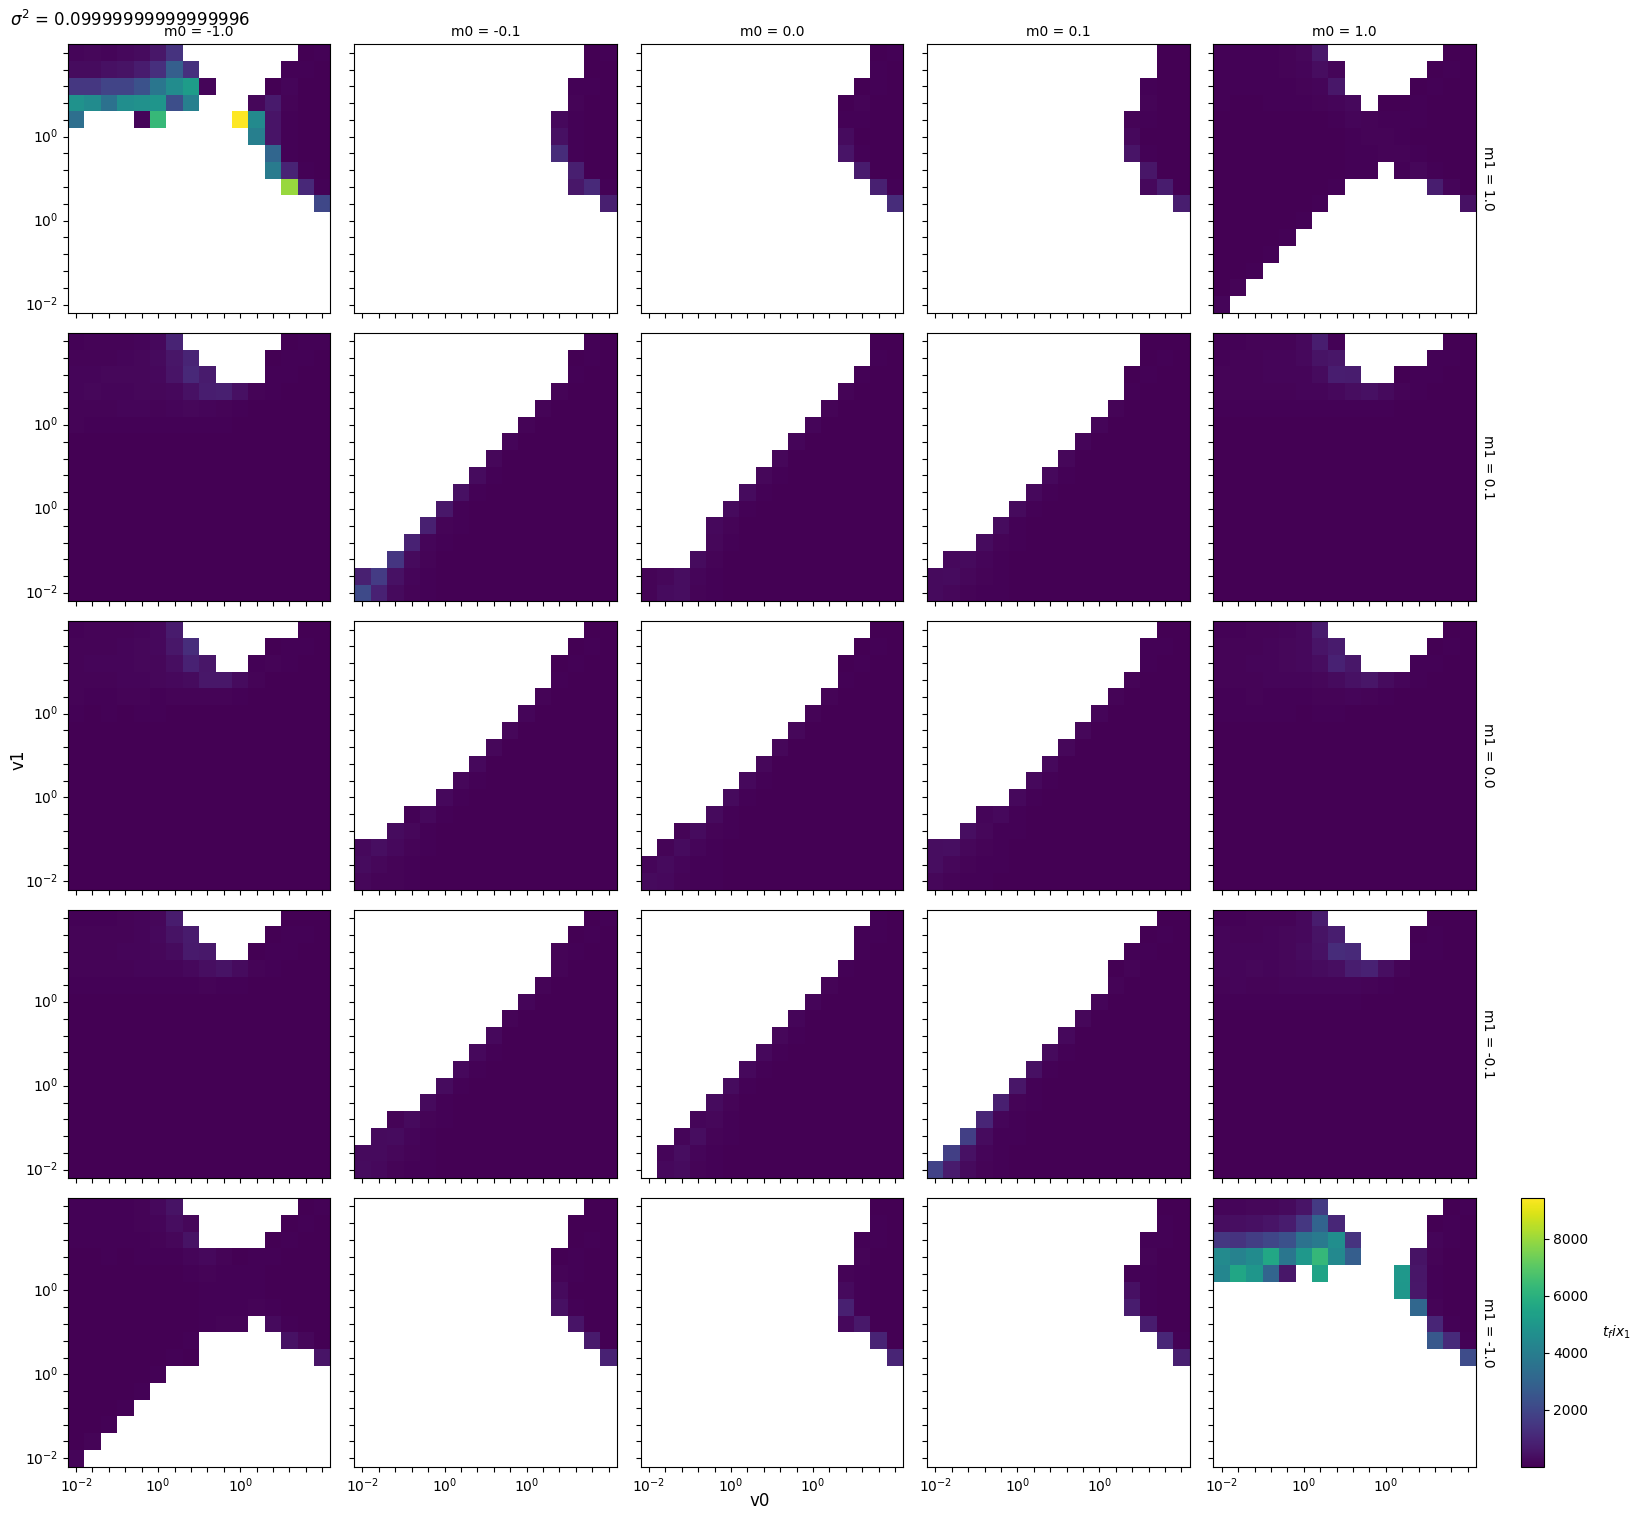

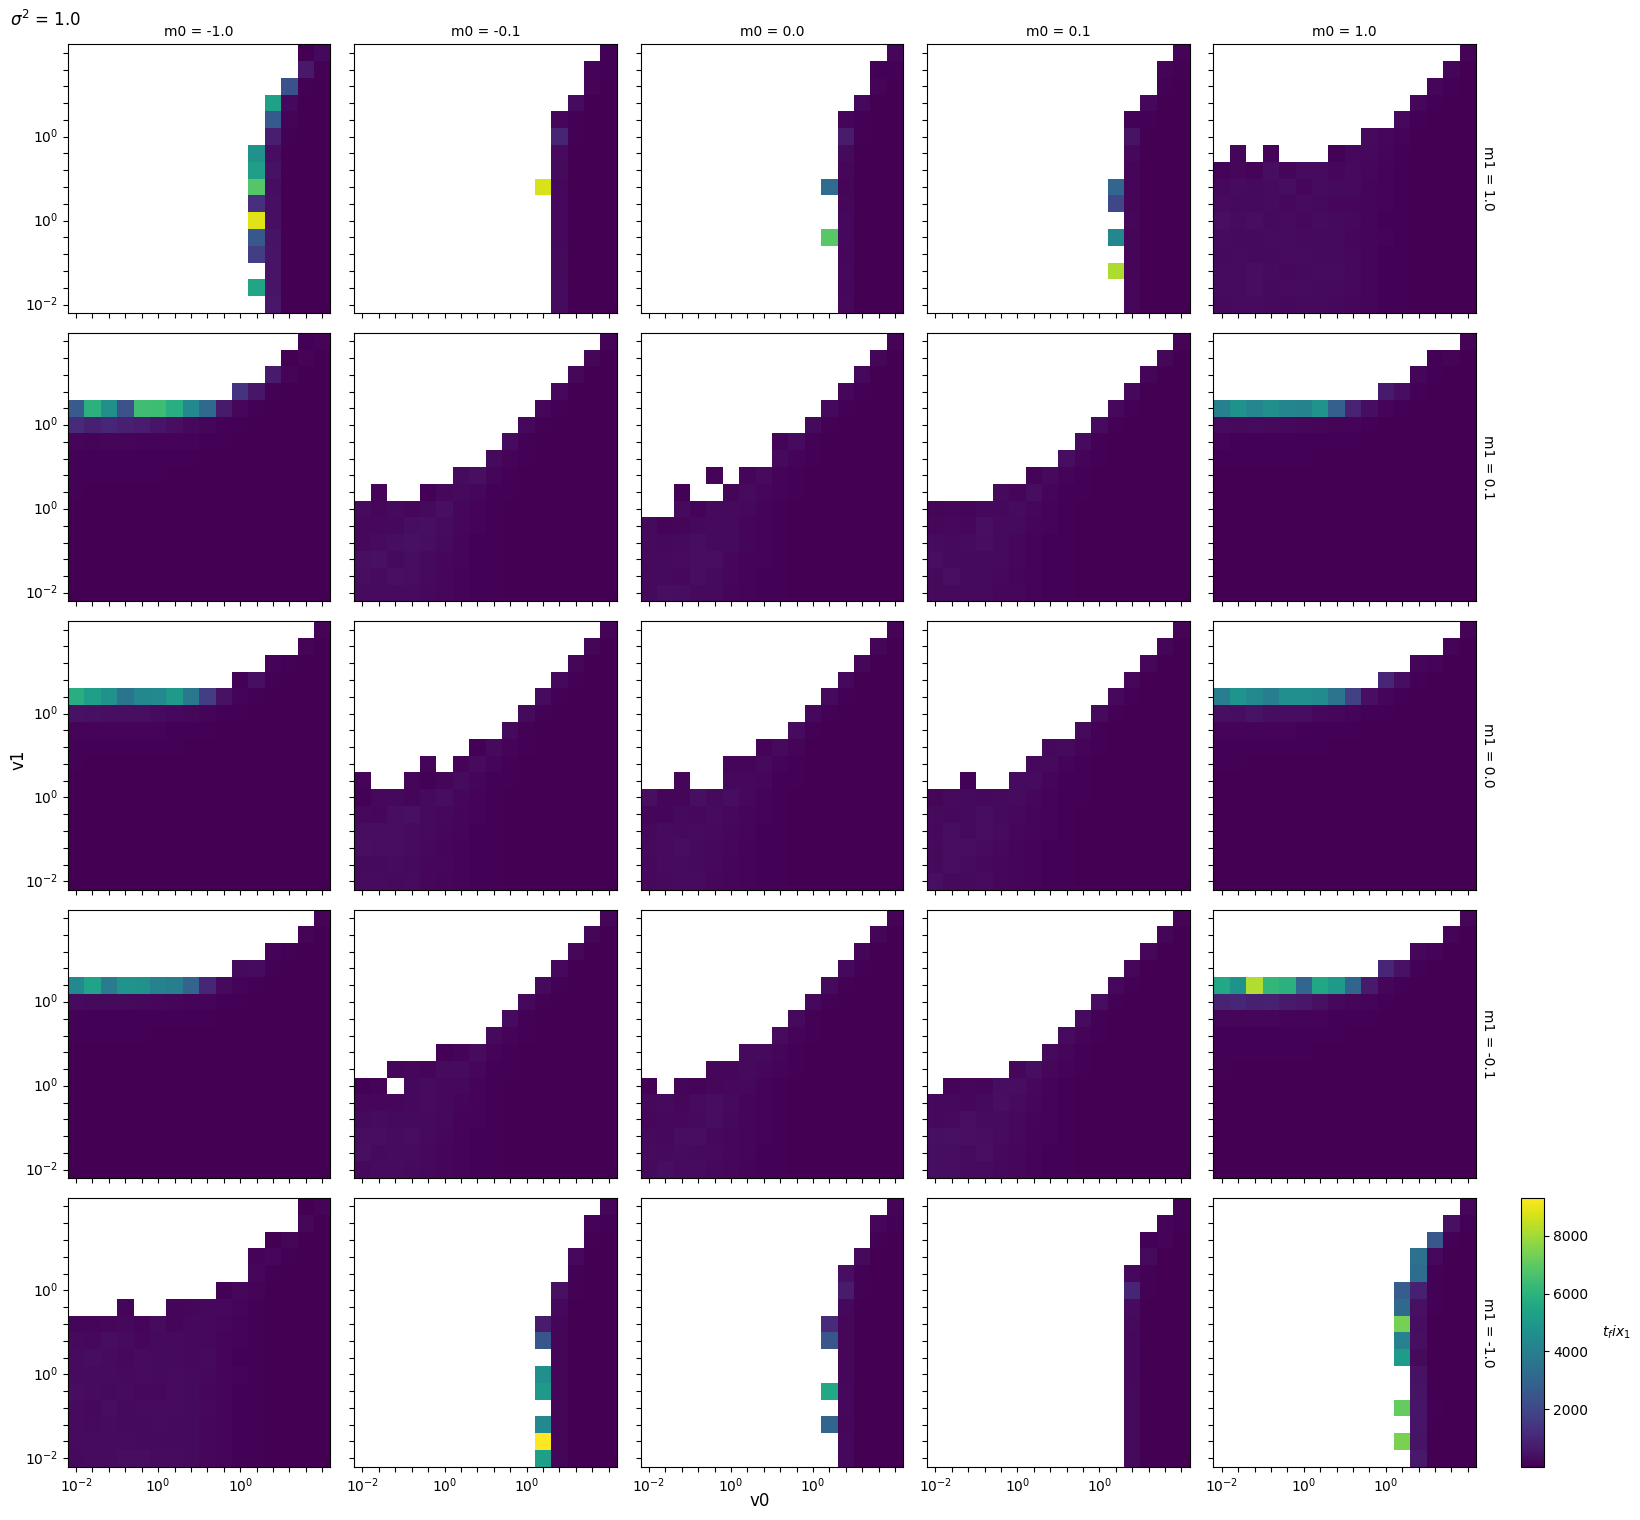

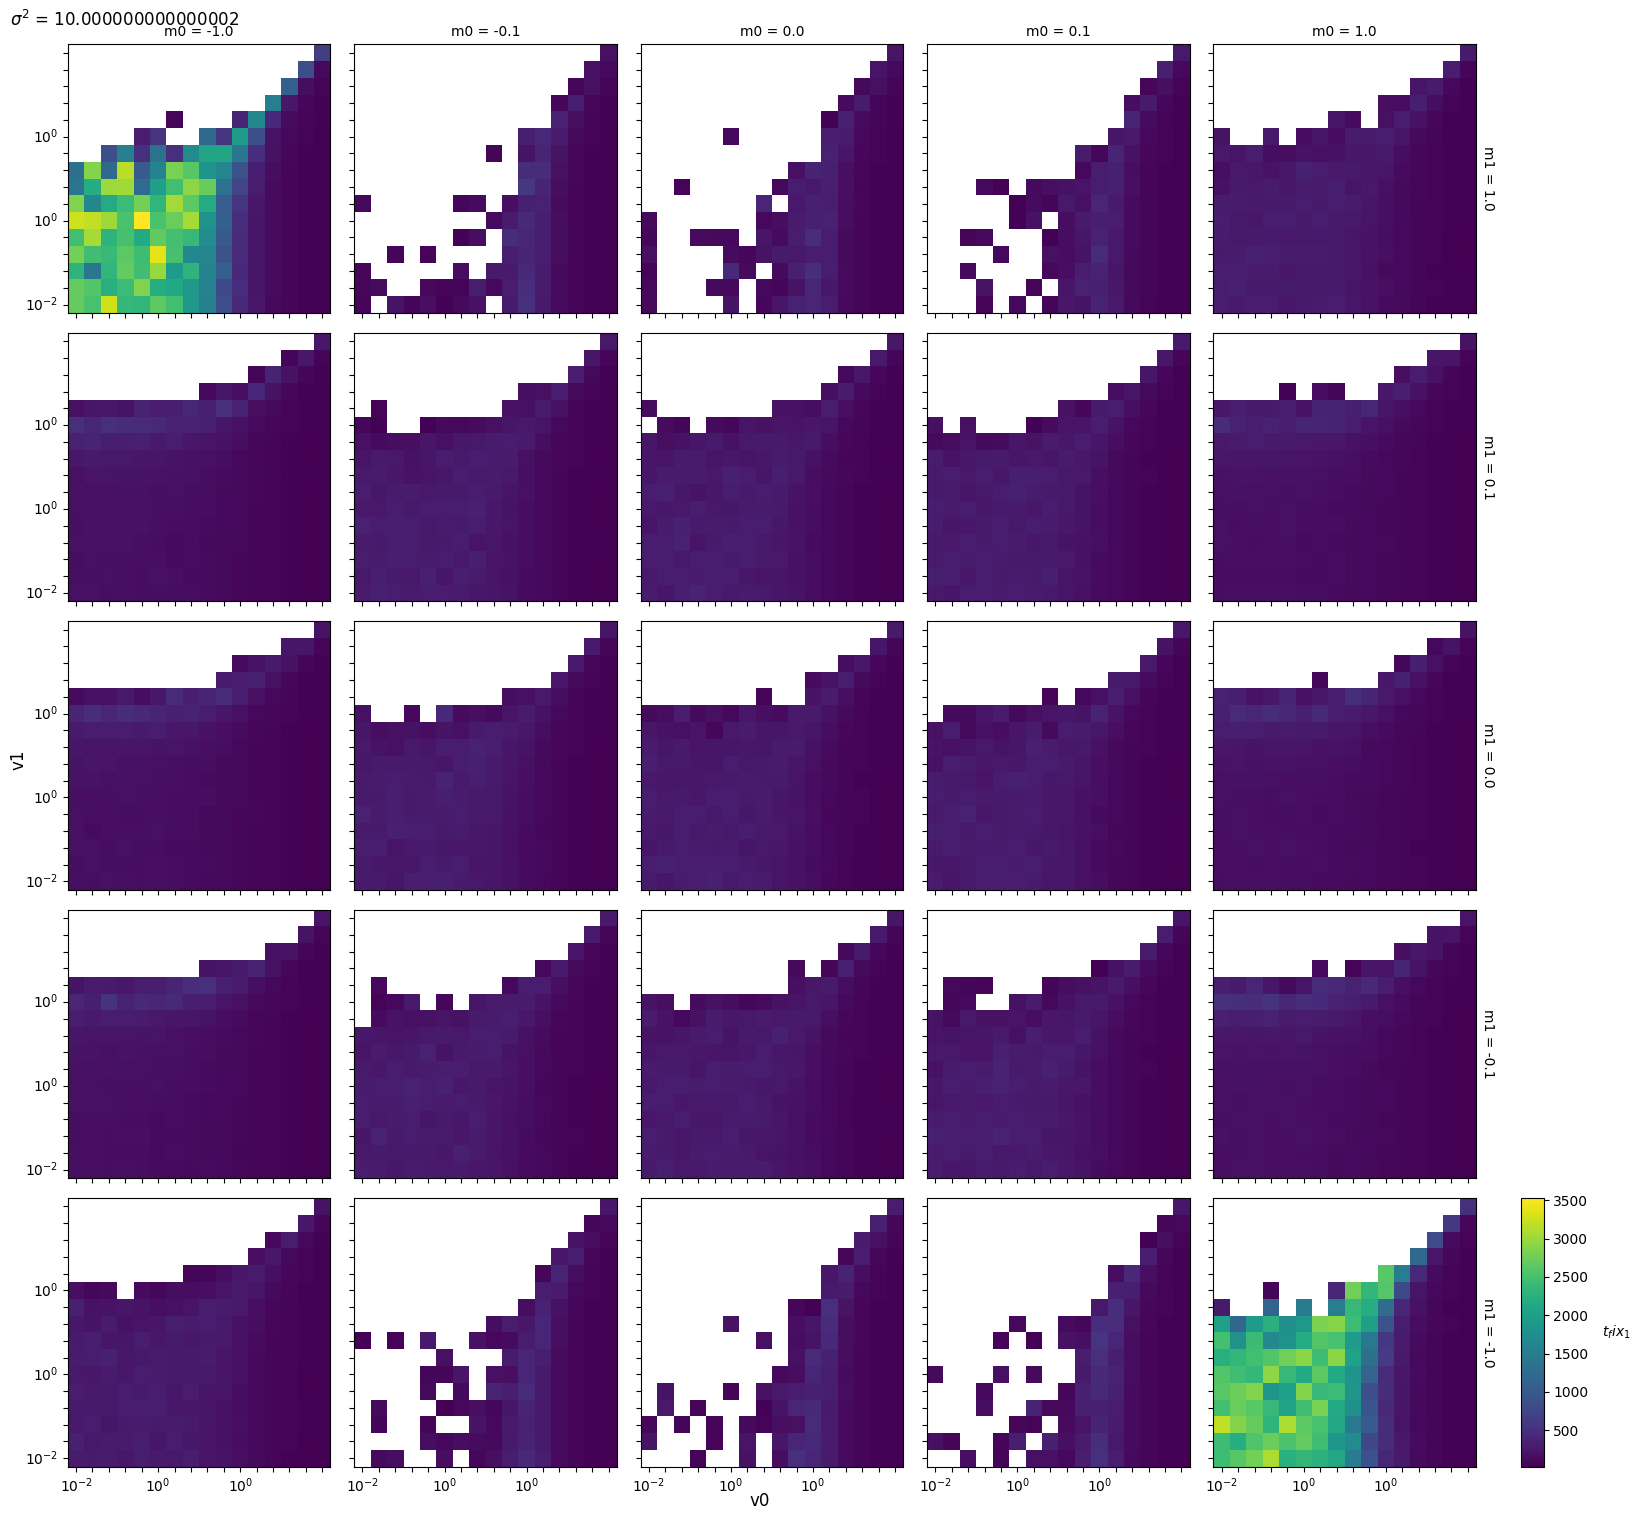

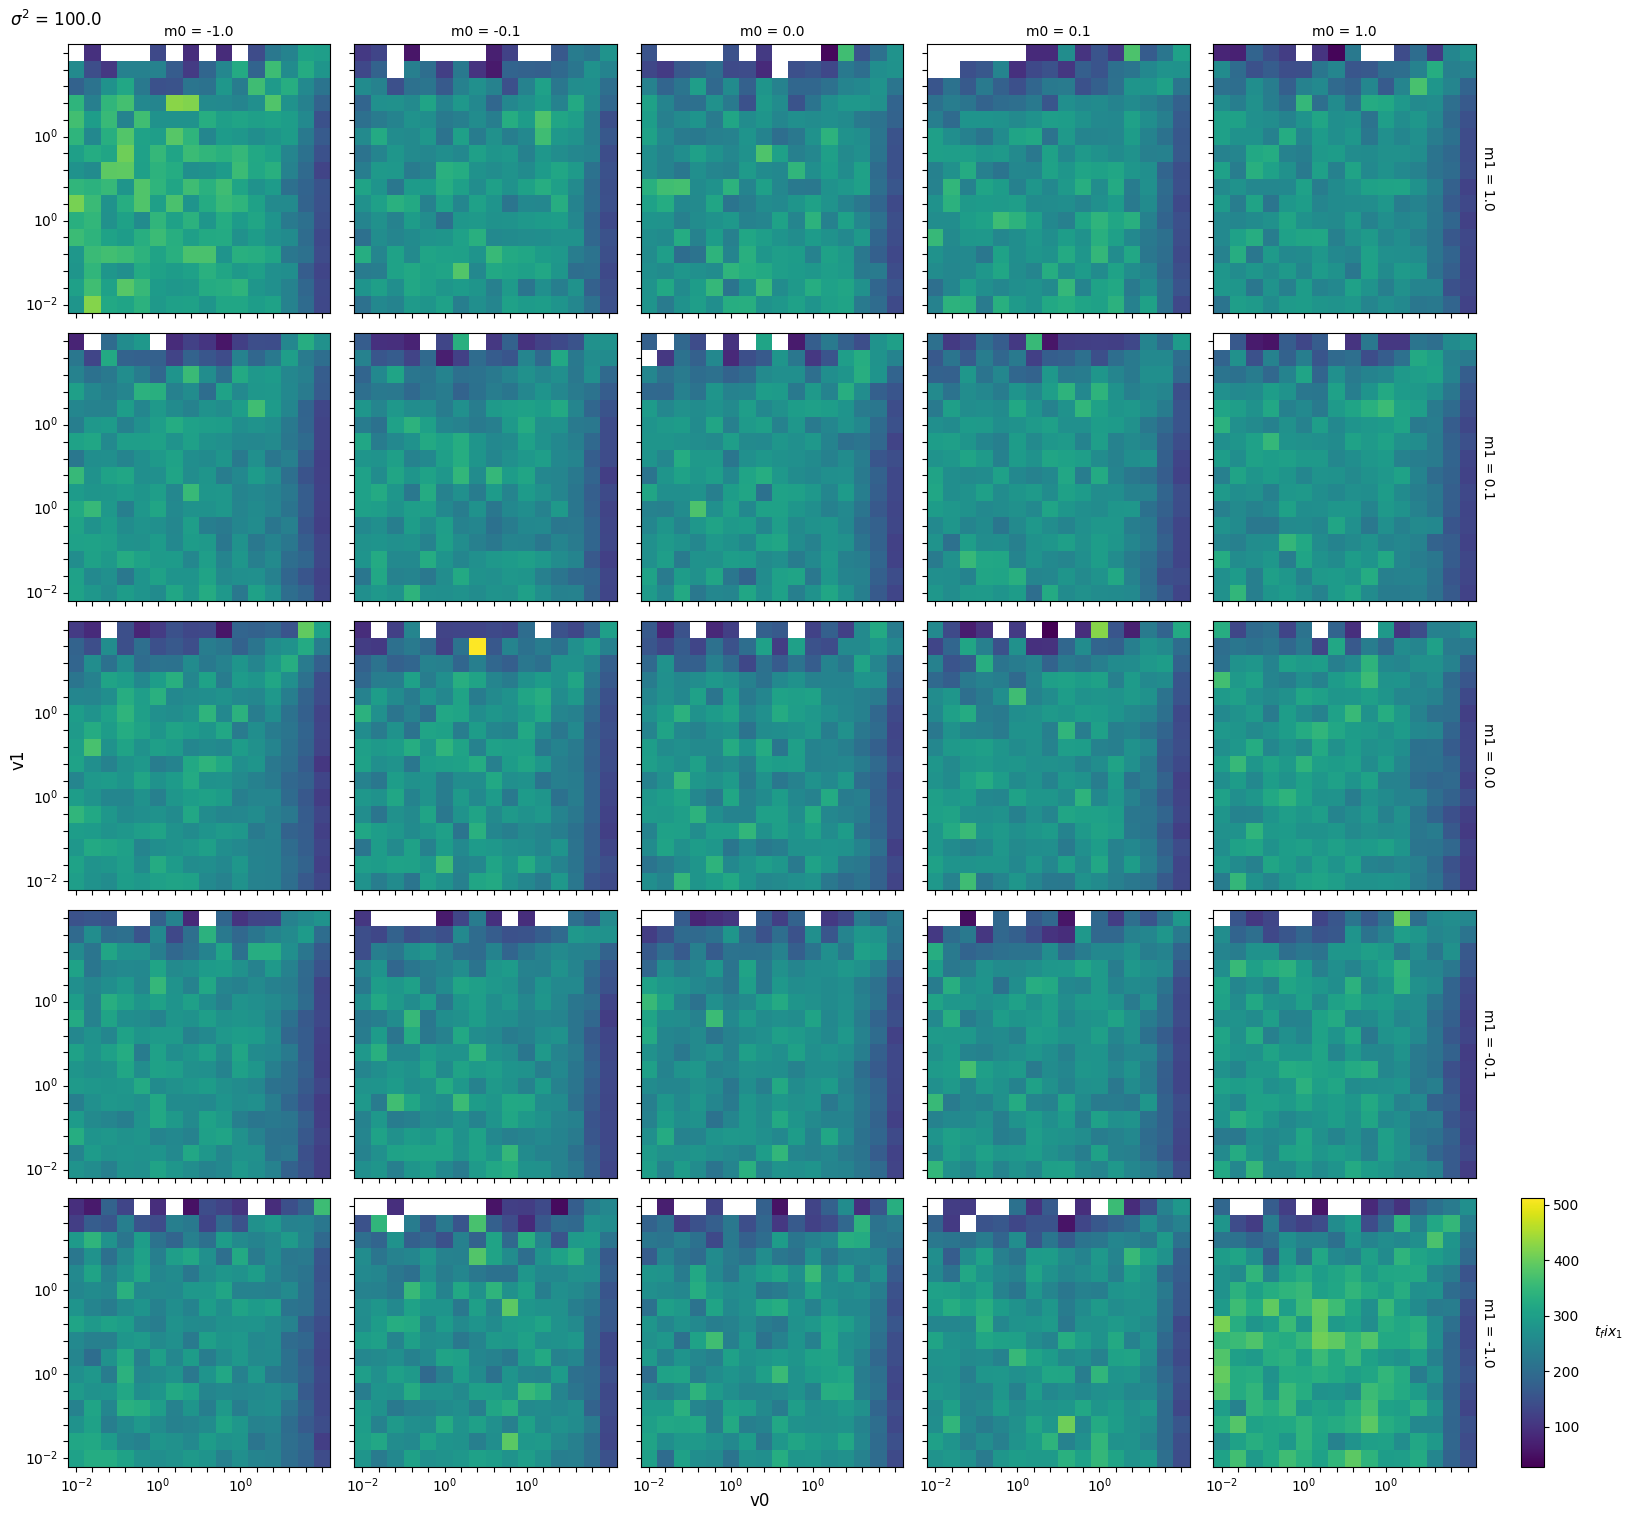

In [31]:
value_col = "t_fix_1"   # the column you want to color by

for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]

    # choose vmin/vmax globally or per-sigma:
    vmin = d_smr_sub[value_col].min()
    vmax = d_smr_sub[value_col].max()

    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0",
                      row_order=row_order_m, col_order=col_order_m,
                      margin_titles=True)

    # pass value_col (and cmap/vmin/vmax) to your panel function
    g.map_dataframe(heatmap_panel, value_col=value_col, cmap="viridis",
                    vmin=vmin, vmax=vmax)

    g.fig.supxlabel("v0", x=0.5, y=0)
    g.fig.supylabel("v1", y=0.5, x=0)
    g.fig.suptitle(f"$\\sigma^2$ = {sigma ** 2}", x=0, y=1, ha="left")

    # colorbar next to last panel
    last_ax = g.axes[-1, -1]
    pos = last_ax.get_position()
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])

    # same cmap and normalization as used in heatmap
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cbar.set_label(f"${value_col}$", rotation=0, labelpad=10, va="center", ha="left")

    plt.show()

In [35]:
d

,sigma,m0,m1,v0,v1,n_gen,allele_fixed
0,0.316228,-1.0,-1.0,0.01,0.01,38,1.0
1,0.316228,-1.0,-1.0,0.01,0.01,300,0.0
2,0.316228,-1.0,-1.0,0.01,0.01,144,1.0
3,0.316228,-1.0,-1.0,0.01,0.01,95,1.0
4,0.316228,-1.0,-1.0,0.01,0.01,305,0.0
...,...,...,...,...,...,...,...
2559995,10.000000,1.0,1.0,10.00,10.00,282,0.0
2559996,10.000000,1.0,1.0,10.00,10.00,554,0.0
2559997,10.000000,1.0,1.0,10.00,10.00,607,1.0
2559998,10.000000,1.0,1.0,10.00,10.00,354,1.0


In [34]:
d_smr[d_smr["t_fix_1"].isna()]

,sigma,m0,m1,v0,v1,p_ext,p_fix_1,t_fix_1,log_v0,log_v1
16,0.316228,-1.0,-1.0,0.015849,0.010000,0.0,0.0,NaN,-1.8,-2.0
32,0.316228,-1.0,-1.0,0.025119,0.010000,0.0,0.0,NaN,-1.6,-2.0
33,0.316228,-1.0,-1.0,0.025119,0.015849,0.0,0.0,NaN,-1.6,-1.8
48,0.316228,-1.0,-1.0,0.039811,0.010000,0.0,0.0,NaN,-1.4,-2.0
49,0.316228,-1.0,-1.0,0.039811,0.015849,0.0,0.0,NaN,-1.4,-1.8
...,...,...,...,...,...,...,...,...,...,...
25103,10.000000,1.0,0.1,0.010000,10.000000,0.0,0.0,NaN,-2.0,1.0
25215,10.000000,1.0,0.1,0.251189,10.000000,0.0,0.0,NaN,-0.6,1.0
25439,10.000000,1.0,1.0,0.100000,10.000000,0.0,0.0,NaN,-1.0,1.0
25503,10.000000,1.0,1.0,0.630957,10.000000,0.0,0.0,NaN,-0.2,1.0


In [47]:
d[(d["sigma"] == 10) & (d["m0"] == 1) & (d["m1"] == 0.1) & (d["v0"] == 0.01) & (d["v1"] == 10)]["n_gen"].mean()

np.float64(137.08)

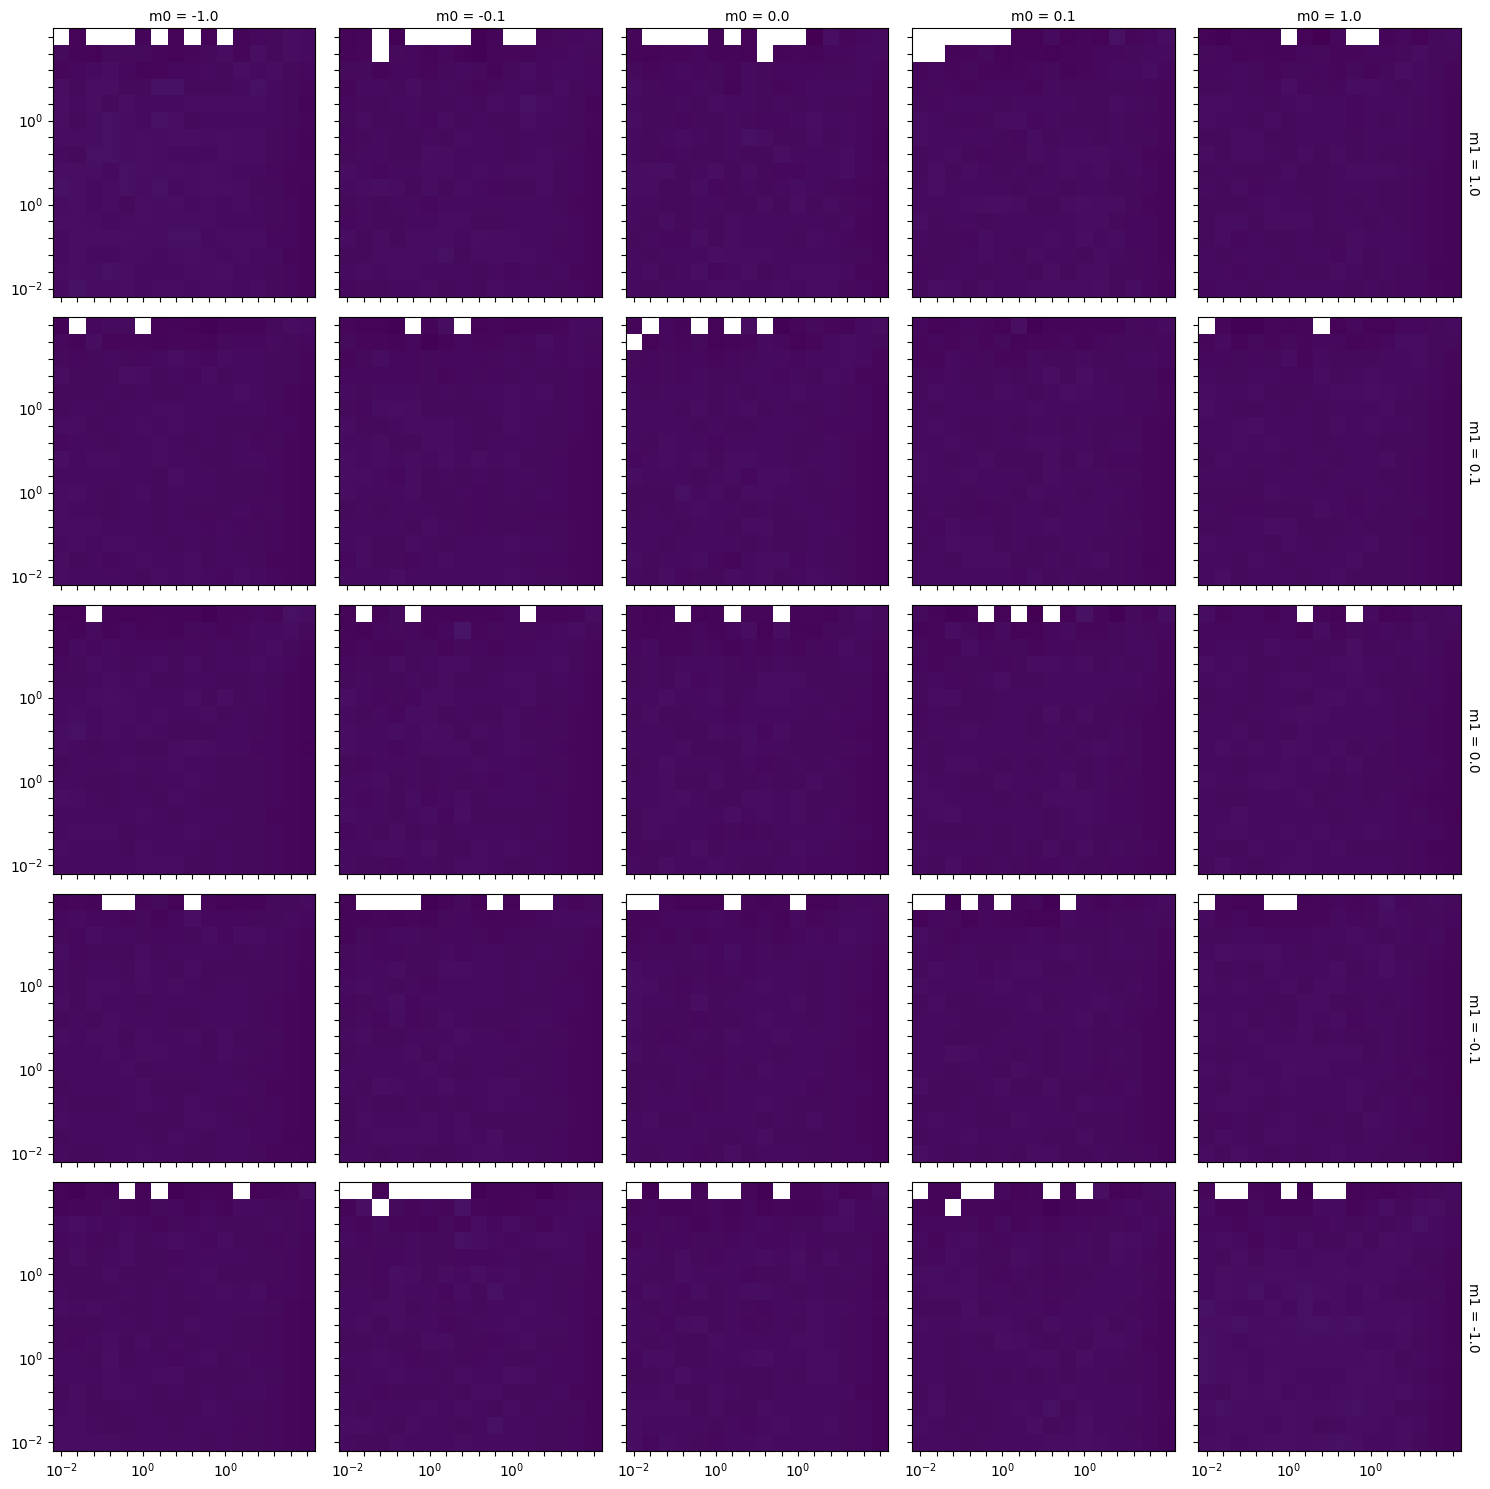

In [28]:
value_col = "t_fix_1"  # column you want to color by

# choose vmin/vmax globally or per-subset
vmin = d_smr[value_col].min()
vmax = d_smr[value_col].max()

g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
g.map_dataframe(heatmap_panel, value_col=value_col, cmap="viridis", vmin=vmin, vmax=vmax)


# build the colorbar using same cmap/norm and label
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(f"${value_col}$", rotation=0, labelpad=10, va='center', ha='left')

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_218361/3153383930.py:7: SyntaxWarning: invalid escape sequence '\s'
  g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')


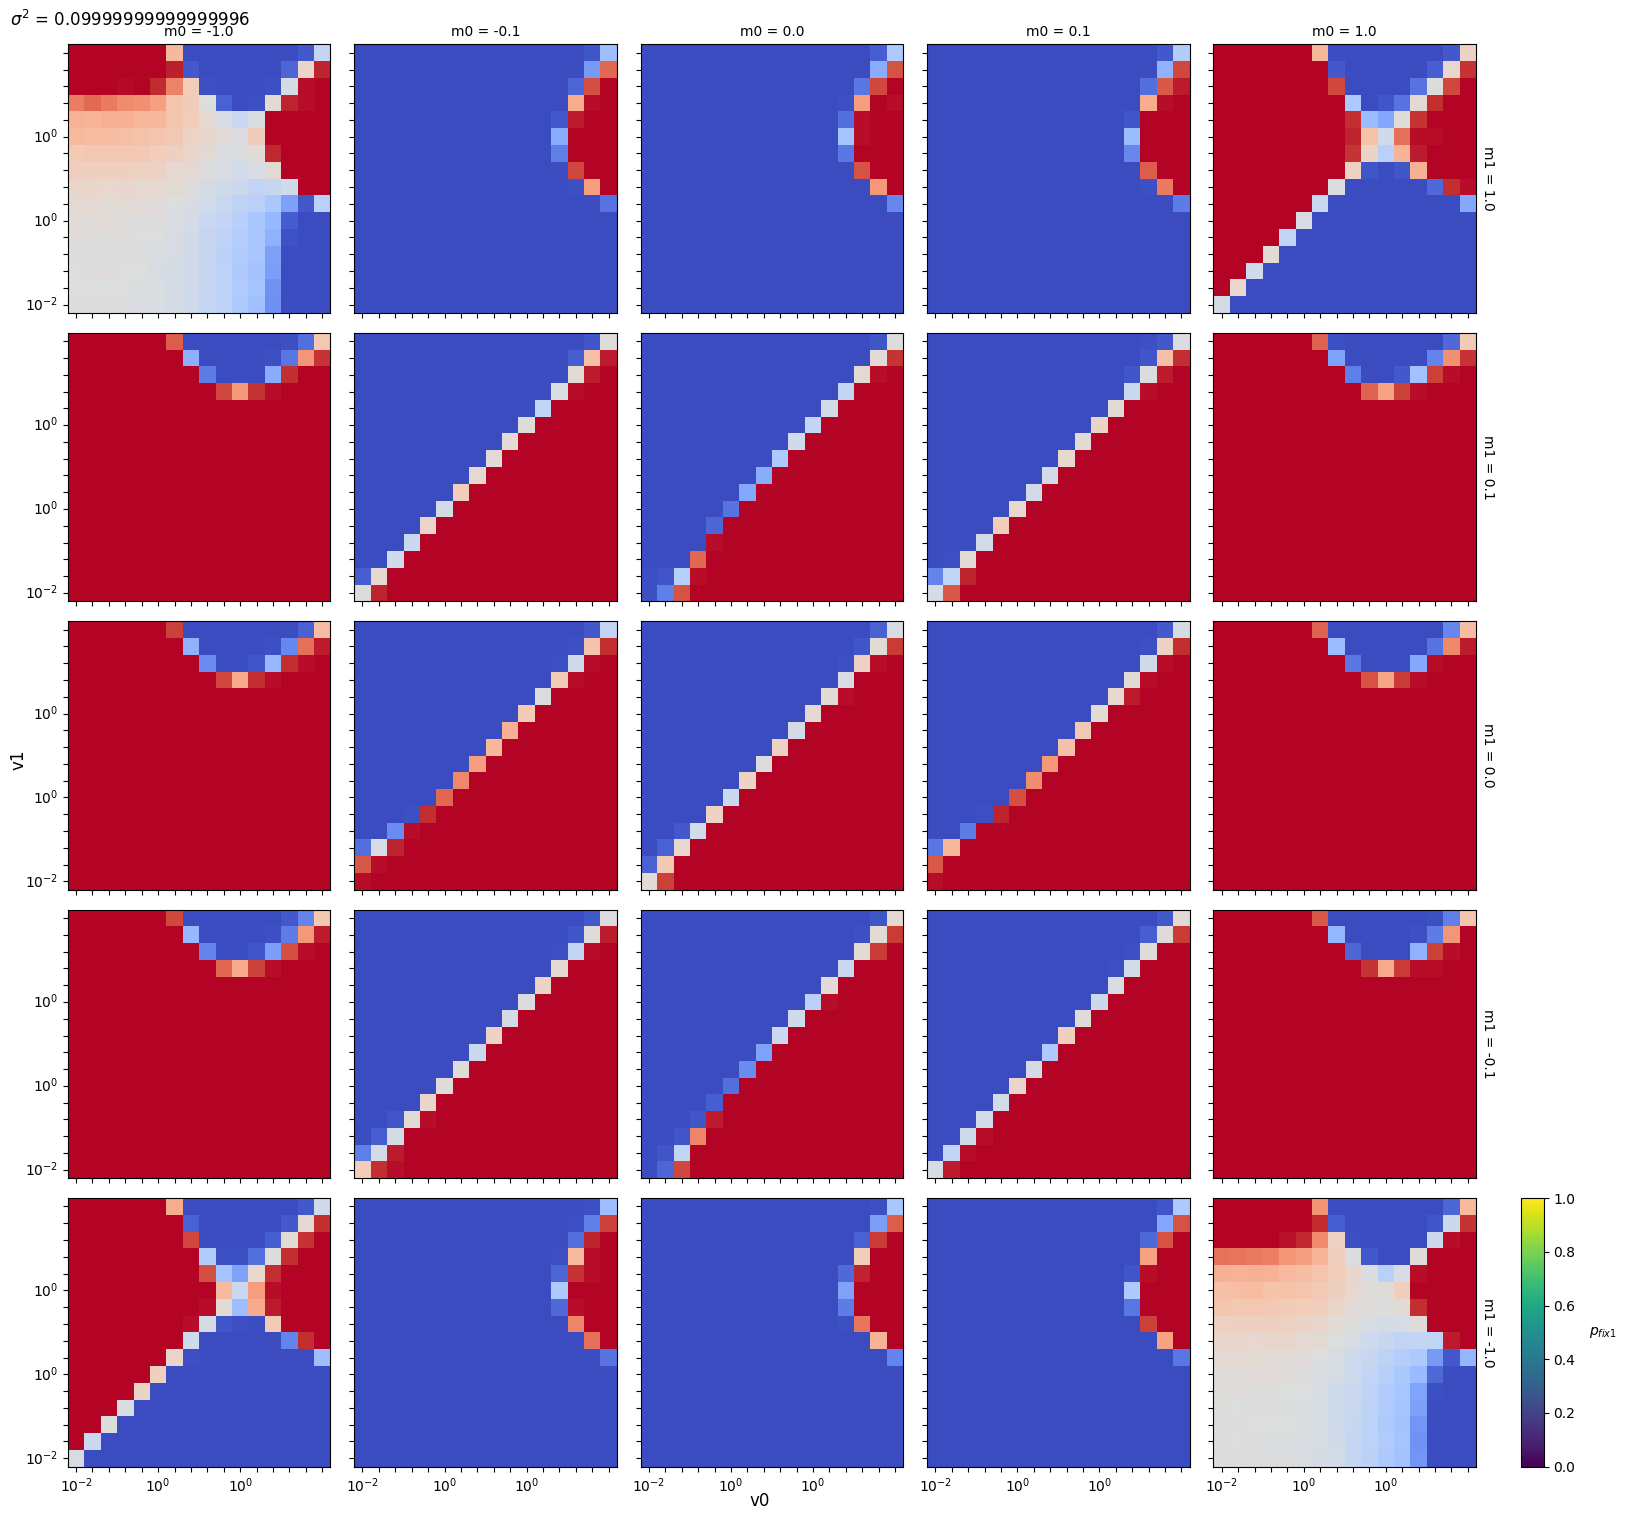

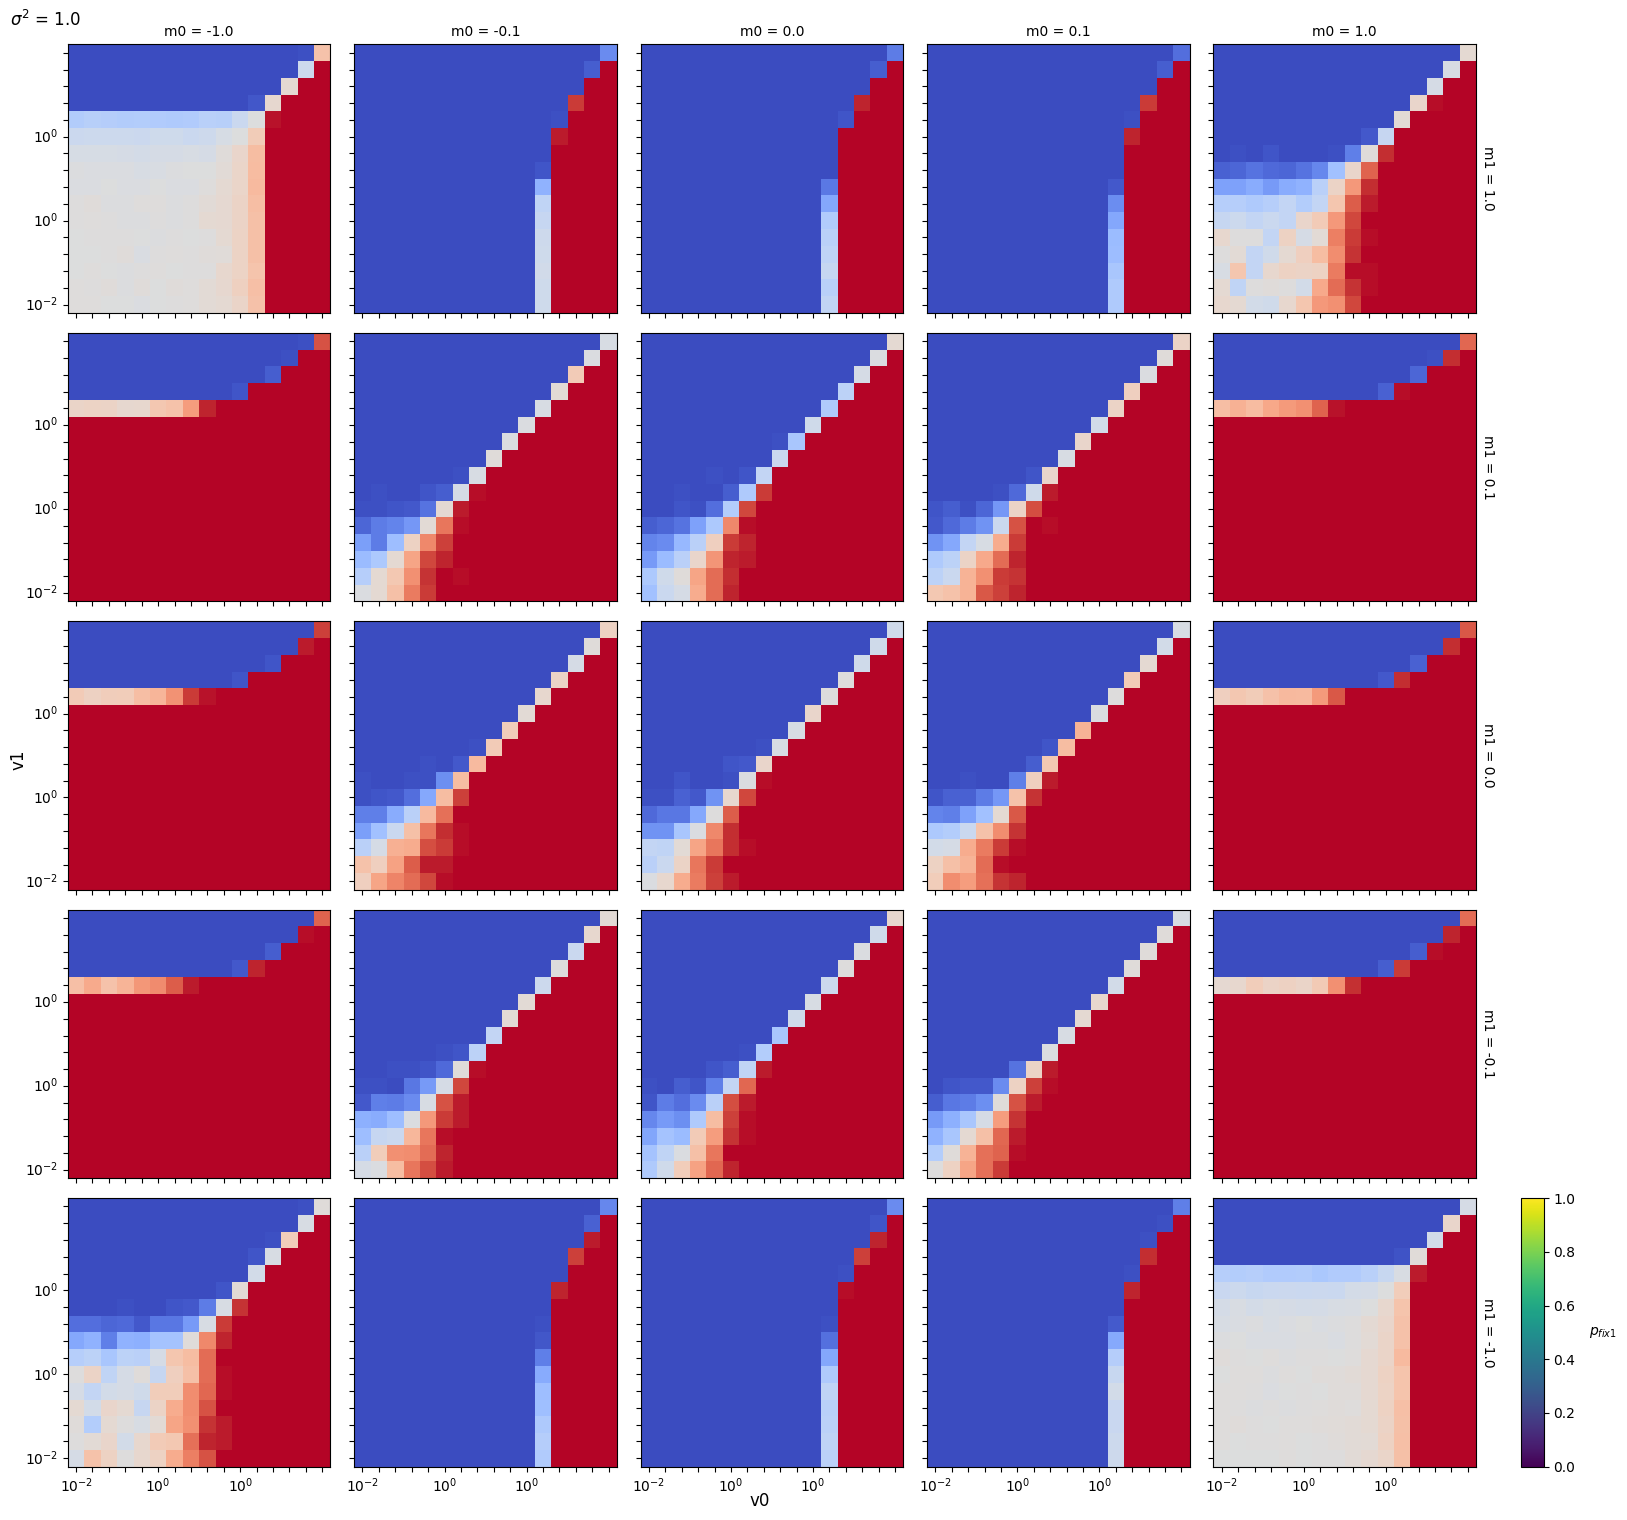

/tmp/ipykernel_218361/3153383930.py:7: SyntaxWarning: invalid escape sequence '\s'
  g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x74dbfea1c9a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [29]:
for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]
    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
    g.map_dataframe(heatmap_panel)
    g.fig.supxlabel("v0", x = 0.5, y = 0)
    g.fig.supylabel('v1', y = 0.5, x = 0)
    g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')
    
    # Add a colorbar next to the last panel
    # Compute position of the last panel
    last_ax = g.axes[-1, -1]  # last row, last column
    pos = last_ax.get_position()  # Bbox
    
    # Create a new Axes for the colorbar: slightly thinner than a panel
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
    # Use the same colormap and normalization
    sm = plt.cm.ScalarMappable(cmap="viridis")
    sm.set_array([])
    #g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')
    
    plt.show()

In [27]:
d_smr

,sigma,m0,m1,v0,v1,p_ext,p_fix_1,t_fix_1,log_v0,log_v1
0,0.316228,-1.0,-1.0,0.01,0.010000,0.0,0.48,126.229167,-2.0,-2.0
1,0.316228,-1.0,-1.0,0.01,0.015849,0.0,1.00,39.010000,-2.0,-1.8
2,0.316228,-1.0,-1.0,0.01,0.025119,0.0,1.00,19.350000,-2.0,-1.6
3,0.316228,-1.0,-1.0,0.01,0.039811,0.0,1.00,13.130000,-2.0,-1.4
4,0.316228,-1.0,-1.0,0.01,0.063096,0.0,1.00,9.030000,-2.0,-1.2
...,...,...,...,...,...,...,...,...,...,...
25595,10.000000,1.0,1.0,10.00,1.584893,0.0,0.96,147.968750,1.0,0.2
25596,10.000000,1.0,1.0,10.00,2.511886,0.0,0.98,163.948980,1.0,0.4
25597,10.000000,1.0,1.0,10.00,3.981072,0.0,0.96,181.885417,1.0,0.6
25598,10.000000,1.0,1.0,10.00,6.309573,0.0,0.79,243.240506,1.0,0.8


In [58]:
np.array([1,1])[:,np.newaxis]

array([[1],
       [1]])

In [52]:
?hanoi.fit_multimodal

Signature: hanoi.fit_multimodal(sigma, p, z_opt, z)
Docstring:
Computes fitness based on a multimodal fitness function.

Arguments:
    sigma:  (n_peaks,) array specifying SD of n_peak peaks
    p:      (n_peaks,) array specifying relative height of peaks
    z_opt:  (n_peaks, n) array specifying the coordinate of n_peak peaks in the n-dimensional phenotype space
    z:      (N, n) array representing n-dimensional phenotypes of N individuals.
Returns: (N,) array representing fitness of N individuals
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function

In [61]:
hanoi.fit_multimodal(sigma = np.array([1,1]), p = np.array([1,1]), z_opt = np.array([0, 1]).reshape([2,1]), z = np.linspace(0,1, 11).reshape([11,1]))

array([1.60653066, 1.66198929, 1.70634771, 1.73870202, 1.75838656,
       1.76499381, 1.75838656, 1.73870202, 1.70634771, 1.66198929,
       1.60653066])